In [1]:
import galsim
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
import batsim
# import cupyx.scipy.fft as cp_fft

from time import time
from tqdm import tqdm

#print(cp.cuda.is_available())

/home/b7009348/miniconda3/envs/batsim-gpu/lib/python3.10/site-packages/cupy/_environment.py:596: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [2]:
def fft_on_gpu(image):
    # Execute the FFT on the GPU and shift the zero-frequency component to the center of the spectrum.
    return cp.fft.fftshift(cp.fft.fft2(cp.fft.ifftshift(image)))

def ifft_on_gpu(image_fft):
    # Execute the inverse FFT on the GPU and shift back.
    return cp.fft.fftshift(cp.fft.ifft2(cp.fft.ifftshift(image_fft)))

def pixel_fft_gpu_shifted(n, fine_scale, pixel_scale):
    kfreq = 2 * cp.pi * cp.fft.fftshift(cp.fft.fftfreq(n, d=fine_scale))
    ky, kx = cp.meshgrid(kfreq, kfreq, indexing="ij")

    pix_fft = cp.sinc(kx * pixel_scale / (2 * cp.pi))
    pix_fft *= cp.sinc(ky * pixel_scale / (2 * cp.pi))
    

    return pix_fft.astype(cp.complex64)

In [3]:
use_pixel = True   # Whether to include the pixel response
supersample = 128   # Super-sample grid size for direct FFT approach
pad = 16           # Extra padding around image to ignore distant flux from FFTs
scale = 0.2        # Pixel scale of the output image

# Construct psf and galaxy profiles
psf = galsim.Moffat(beta=3.5, fwhm=0.7)
gal = galsim.Sersic(n=5, half_light_radius=0.2, flux=1)
objs = [gal, psf]
conv_gal = galsim.Convolve(objs)

# Determine image size
# Use the convolved profile's own good image size rather than the pre-convolution galaxy size.
size = conv_gal.getGoodImageSize(scale)
fft_size = size + 2*pad
fine_scale = scale / supersample
fine_fft_size = fft_size * supersample
print(fine_fft_size, fine_scale)
dk = 2 * np.pi / (fine_fft_size * fine_scale)

start = time()
compact_size = gal.getGoodImageSize(fine_scale)
print(compact_size)
# gal_im = gal.drawImage(nx=compact_size, ny=compact_size, scale=fine_scale,
#                        method="no_pixel", use_true_center=False).array
stamp = batsim.Stamp(nn=fine_fft_size, scale=fine_scale)
coords = stamp.coords
coords = cp.asnumpy(coords).astype(np.float64)
gal_im = batsim._gsinterface.getFluxVec(fine_scale, gal._sbp, coords)

# Draw the PSF either directly in k-space or in real space and then fft.
# psf_fft = psf.drawKImage(nx=fine_fft_size, ny=fine_fft_size, scale=dk).array
# psf_fft = cp.asarray(psf_fft)
psf_compact = psf.getGoodImageSize(fine_scale)
psf_im = psf.drawImage(nx=fine_fft_size, ny=fine_fft_size, scale=fine_scale, method="no_pixel", use_true_center=False).array

# Draw the pixel if requested.
if use_pixel:
    # Draw the pixel directly in Fourier space, rather than use fft2.
    # The direct fft doesn't work especially well with only a single non-zero pixel.
    # (Nor even when supersampling to sxs pixels.)
    # pix_fft = galsim.Pixel(scale).drawKImage(nx=fine_fft_size, ny=fine_fft_size, scale=dk).array
    # pix_fft = cp.asarray(pix_fft)

    pix_fft = pixel_fft_gpu_shifted(
        n=fine_fft_size,
        fine_scale=fine_scale,
        pixel_scale=scale,
    )
end = time()
print(f"Draw time: {end - start:.4f} seconds")

start = time()
# Send to GPU
gal_im = cp.asarray(gal_im)
psf_im = cp.asarray(psf_im)
#Execute the FFT on the GPU and shift the zero-frequency component to the center of the spectrum.
gal_fft = fft_on_gpu(gal_im)
psf_fft = fft_on_gpu(psf_im)
end = time()
print(f"FFT time: {end - start:.4f} seconds")

start = time()
# Convolve and IFFT
bat_conv_fft = gal_fft * psf_fft
if use_pixel:
    bat_conv_fft *= pix_fft
bat_conv_im = ifft_on_gpu(bat_conv_fft)

# Recover the coarse-grid image by taking the matching fine-grid sample phase and multiplying by
# the area ratio.
if supersample > 1:
    bat_conv_im = (supersample**2) * bat_conv_im[::supersample, ::supersample]
end = time()
print(f"Conv time: {end - start:.4f} seconds")

start = time()
# Draw a padded GalSim image too
draw_method = "auto" if use_pixel else "no_pixel"
gal_conv_im = conv_gal.drawImage(
    nx=fft_size, ny=fft_size, scale=scale, method=draw_method, use_true_center=False
).array
end = time()
print(f"GalSim draw time: {end - start:.4f} seconds")

# Crop both images to the same central region before computing the residual.
gal_conv_im = gal_conv_im[pad:pad+size, pad:pad+size]
bat_conv_im = bat_conv_im[pad:pad+size, pad:pad+size]

# Move back to CPU for comparison and plotting.
bat_conv_im = cp.asnumpy(bat_conv_im).real

# clean up GPU memory
cp._default_memory_pool.free_all_blocks()
cp._default_pinned_memory_pool.free_all_blocks()

residual = gal_conv_im - bat_conv_im
print(f"Mode: {'with pixel' if use_pixel else 'no pixel'}")
print(f"Supersample: {supersample}")
print(f"GalSim flux: {gal_conv_im.sum():.8f}")
print(f"FFT flux:    {bat_conv_im.sum():.8f}")
print(f"Max abs residual: {abs(residual).max():.3e}")

perc_residual = 100 * abs(residual).max() / gal_conv_im.max()
print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")

# Plot
plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gal_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("GalSim Convolution")
plt.subplot(1, 3, 2)
plt.imshow(bat_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Direct FFT Convolution")
plt.subplot(1, 3, 3)
plt.imshow(residual, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Residual (Galsim - BATSim)")
plt.savefig('charlie.png')

14336 0.0015625
9692


/home/b7009348/FPFS-project/BATSim/src/batsim/stamp.py:75: RuntimeWarning: CuPy unavailable; falling back to NumPy stamp coordinates.
  self.xp = _get_array_backend() if backend is None else backend


CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

In [4]:
def galsim_sampling_hint(obj, pixel_scale, safety=2.0,integration_order=2, attenuation_target=0.05):
    """
    Estimate supersampling from GalSim's internal maxk/stepk style scale info.
    """
    maxk = float(obj.maxk)
    coarse_nyquist = np.pi / float(pixel_scale)

    raw = safety * maxk / coarse_nyquist

    q = max(1, int(integration_order))

    if q <= 1:
        effective = raw
    else:
        # Block integration behaves approximately like a square/tophat
        # prefilter over the FFT-grid cell. Its Fourier response is sinc-like.
        #
        # Rather than using a fixed empirical division, use q to define the
        # strongest plausible reduction. q=2 usually permits about 4--8x less
        # effective supersampling in your tests, so q^2 is a reasonable base.
        #
        # attenuation_target lets you tune how much high-k leakage you tolerate.
        integration_reduction = q ** 2 / attenuation_target**0.5

        # Avoid absurd reductions for high q.
        integration_reduction = min(integration_reduction, 8.0 * q)

        effective = raw / integration_reduction

        # Do not allow the requested effective supersampling to fall below q,
        # otherwise fft_supersample may collapse too aggressively.
        effective = max(effective, q)

    # Round up to power of two
    s_pow2 = 2 ** int(np.ceil(np.log2(max(1, effective))))

    return int(np.clip(s_pow2, 1, 1024))

gal = galsim.Sersic(n=3, half_light_radius=0.2)

print(gal.maxk)
print(gal.nyquist_scale)

supersample = galsim_sampling_hint(gal, pixel_scale=scale)
print(f"Recommended supersampling: {supersample}")

538.1658703643784
0.005837591766015747
Recommended supersampling: 8


Recommended supersampling: 32
Grid sizing: sim_ngrid=1340, supersample=32, integration_order=2, fft_supersample=8, fine_ngrid=4096, fine_compact=10712, max_fine_grid=4096
Stamp construction took 0.086 seconds
Build coordinates and transforms took 0.872 seconds
Transfer coords to CPU took 0.000 seconds
Galaxy sampling took 0.224 seconds
Transfer galaxy profile to NumPy took 0.000 seconds
Block integration compensation took 0.070 seconds
Sampling PSF spectrum took 0.021 seconds
Transfer PSF spectrum to NumPy took 0.000 seconds
FFT and convolution took 1.219 seconds
BATSim simulation time: 2.4040 seconds
GalSim draw time: 0.0889 seconds
GalSim flux: 3.52486086
BATSim flux:    3.56863308
Max abs residual: 3.502e-04
Max abs residual as % of max flux: 0.635%


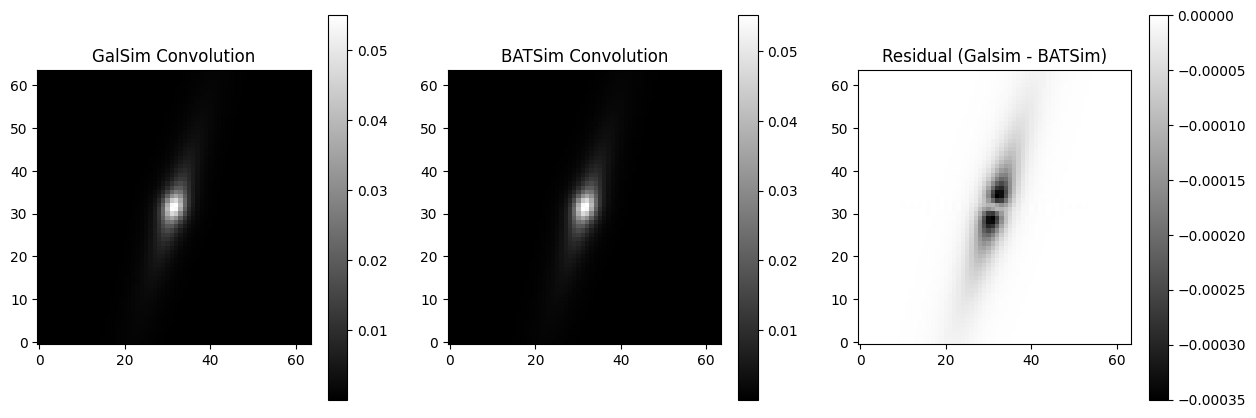

In [7]:
draw_method = "auto"
scale = 0.2 # Pixel scale of the output image

# Construct psf and galaxy profiles
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

cosmos = galsim.COSMOSCatalog()

gal = cosmos.makeGalaxy(index=29024, gal_type="parametric")
#gal = galsim.Sersic(n=1, half_light_radius=0.2, flux=1).shear(g1=0.2, g2=0.5)
objs = [gal.shear(g1=0.05), psf]
conv_gal = galsim.Convolve(objs)
#conv_gal = conv_gal.shift(0.5*scale, 0.5*scale)

supersample = galsim_sampling_hint(gal, pixel_scale=scale)
print(f"Recommended supersampling: {supersample}")

start = time()
LensTransform = batsim.LensTransform(
    gamma1=0.05,
    gamma2=0.0,
    kappa=0.0,
    backend=None
)
# Simulate using BATSim
bat_conv_im = batsim.simulate_galaxy(
    gal_obj=gal,
    scale=scale,
    psf_obj=psf,
    transform_obj=LensTransform,
    ngrid=64,
    precision="single",
    draw_method=draw_method,
    profile=True,
    pad=16,
    psf_mode="kvalue",
    max_supersample=32,
    min_supersample=4,
    max_fine_grid=4096,
    integration_order=2,
    force_input_flux=True,
    backend="numpy"
)
im_size = bat_conv_im.shape
end = time()
print(f"BATSim simulation time: {end - start:.4f} seconds")

start = time()
# Draw a padded GalSim image too
gal_conv_im = conv_gal.drawImage(
    nx=im_size[0], ny=im_size[1], scale=scale, method=draw_method, use_true_center=True
).array
end = time()
print(f"GalSim draw time: {end - start:.4f} seconds")

residual = gal_conv_im - bat_conv_im
print(f"GalSim flux: {gal_conv_im.sum():.8f}")
print(f"BATSim flux:    {bat_conv_im.sum():.8f}")
print(f"Max abs residual: {abs(residual).max():.3e}")

perc_residual = 100 * abs(residual).max() / gal_conv_im.max()
print(f"Max abs residual as % of max flux: {perc_residual:.3f}%")

# Plot
plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gal_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("GalSim Convolution")
plt.subplot(1, 3, 2)
plt.imshow(bat_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("BATSim Convolution")
plt.subplot(1, 3, 3)
plt.imshow(residual, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Residual (Galsim - BATSim)")
plt.savefig('charlie.png')

In [ ]:
21000 / 4096

5.126953125

In [ ]:
gal = cosmos.makeGalaxy(index=29024, gal_type="parametric")
print(gal.is_axisymmetric)
print(gal.maxk)
print(gal.nyquist_scale)

False
2073.4323740702816
0.0015151652365795003


In [ ]:
print(psf.maxk)

14.493884835704382


4.301843543528006
scale = 1.002208
fractional RMS residual = 0.0024678423
fractional flux residual = 0.0022185752


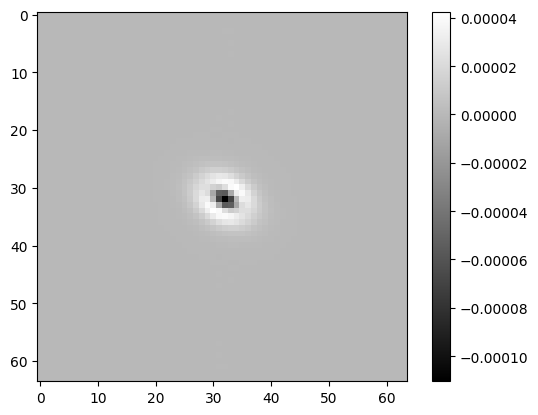

In [ ]:
print(gal.flux)

b = bat_conv_im
g = gal_conv_im

a = np.sum(b * g) / np.sum(b * b)

resid = a * b - g

print("scale =", a)
print("fractional RMS residual =", np.std(resid) / np.std(g))
print("fractional flux residual =", np.sum(resid) / np.sum(g))
plt.imshow(resid, cmap='gray')
plt.colorbar()

In [ ]:
# Clear GPU memory
cp._default_memory_pool.free_all_blocks()
cp._default_pinned_memory_pool.free_all_blocks()

In [ ]:
gal = galsim.Sersic(n=5, half_light_radius=0.2, flux=1)
conv = galsim.Convolve((gal,psf))
sim_ngrid = batsim.sim._resolve_simulation_ngrid(gal, psf, scale)
supersample = batsim.sim._determine_supersampling(gal, scale)

FineGrid = batsim.sim._make_fine_grid(
    conv, scale, sim_ngrid, supersample, pad
)
fine_ngrid = FineGrid.fine_ngrid
fine_compact = FineGrid.fine_compact
print(supersample, fine_ngrid, fine_compact)

TypeError: _determine_supersampling() missing 1 required positional argument: 'integration_order'

In [ ]:
cosmos = galsim.COSMOSCatalog()
inds = np.arange(len(cosmos))
galaxies = cosmos.makeGalaxy(index=inds, gal_type="parametric")

# # Determine grid size
# supersamples = np.empty((len(cosmos)))
# fine_ngrids = np.empty((len(cosmos)))
# fine_compacts = np.empty((len(cosmos)))
# for i, gal in tqdm(enumerate(galaxies)):
#     sim_ngrid = batsim.sim._resolve_simulation_ngrid(gal, psf, scale)
#     supersamples[i] = batsim.sim._determine_supersampling(gal, scale)

#     FineGrid = batsim.sim._make_fine_grid(
#         gal, scale, sim_ngrid, supersamples[i], pad
#     )
#     fine_ngrids[i] = FineGrid.fine_ngrid
#     fine_compacts[i] = FineGrid.fine_compact